In [1]:
import torch

In [2]:
import torch

inputs = torch.tensor(
    [
        [0.43, 0.15, 0.89],  # Your   (x^1)
        [0.55, 0.87, 0.66],  # journey (x^2)
        [0.57, 0.85, 0.64],  # starts  (x^3)
        [0.22, 0.58, 0.33],  # with    (x^4)
        [0.77, 0.25, 0.10],  # one     (x^5)
        [0.05, 0.80, 0.55],  # step    (x^6)
    ],
    dtype=torch.float32
)

print("Shape:", inputs.shape)
print(inputs)

Shape: torch.Size([6, 3])
tensor([[0.4300, 0.1500, 0.8900],
        [0.5500, 0.8700, 0.6600],
        [0.5700, 0.8500, 0.6400],
        [0.2200, 0.5800, 0.3300],
        [0.7700, 0.2500, 0.1000],
        [0.0500, 0.8000, 0.5500]])


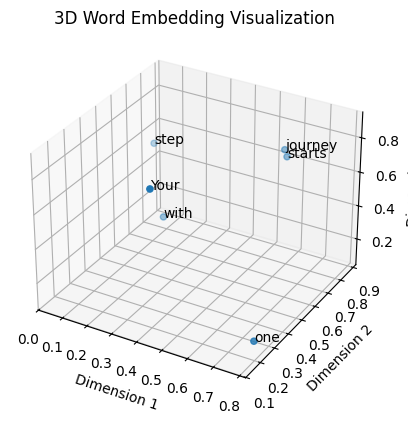

In [4]:
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Corresponding words
words = ['Your', 'journey', 'starts', 'with', 'one', 'step']

# Extract x, y, z coordinates
x_coords = inputs[:, 0].numpy()
y_coords = inputs[:, 1].numpy()
z_coords = inputs[:, 2].numpy()

# Create 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x_coords, y_coords, z_coords)

# Label each point
for i, word in enumerate(words):
    ax.text(x_coords[i], y_coords[i], z_coords[i], word)

ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_zlabel("Dimension 3")

plt.title("3D Word Embedding Visualization")
plt.show()

### Attention scores

In [5]:
query = inputs[1]

attn_scores_2 = torch.empty(inputs.shape[0])
for x,x_i in enumerate(inputs):
  attn_scores_2[i] = torch.dot(x_i,query)

print(attn_scores_2)

tensor([-1.2223e-33,  4.4254e-41,  1.5442e-38,  0.0000e+00,  1.6346e-38,
         1.0865e+00])


### Normalization --->  Simple

In [7]:
attn_scores_2_tmp = attn_scores_2/attn_scores_2.sum()

print(attn_scores_2_tmp)
print(attn_scores_2_tmp.sum())


tensor([-1.1250e-33,  4.0732e-41,  1.4213e-38,  0.0000e+00,  1.5044e-38,
         1.0000e+00])
tensor(1.)


### Normalization by Softmax

In [8]:
import torch

def softmax_stable(x, dim=-1):
    # Subtract max for numerical stability
    x_shifted = x - x.max(dim=dim, keepdim=True).values
    exp_x = torch.exp(x_shifted)
    return exp_x / exp_x.sum(dim=dim, keepdim=True)

In [9]:
attn_weights_2_naive = softmax_stable(attn_scores_2)

In [11]:
print(attn_weights_2_naive)
print(attn_weights_2_naive.sum())

tensor([0.1256, 0.1256, 0.1256, 0.1256, 0.1256, 0.3722])
tensor(1.)


### PYTORCH softmax

In [12]:
attn_weights_2 = torch.softmax(attn_scores_2,dim=0)
print(attn_weights_2)

tensor([0.1256, 0.1256, 0.1256, 0.1256, 0.1256, 0.3722])


### Context Vector

In [13]:
query = inputs[1]

context_vect_2 = torch.zeros(query.shape)
for x, x_i in enumerate(inputs):
  context_vect_2 += attn_weights_2[i] * x_i

print(context_vect_2)

tensor([0.9639, 1.3026, 1.1798])


### Attn Matrix

In [15]:
attn_scores = torch.empty(6,6)

for x,x_i in enumerate(inputs):
  for j,x_j in enumerate(inputs):
    attn_scores[i,j] = torch.dot(x_i,x_j)

print(attn_scores)

tensor([[8.1936e-10, 2.1040e+23, 2.1707e-18, 4.5447e+30, 7.0062e+22, 2.1715e-18],
        [4.5447e+30, 7.0062e+22, 2.1707e-18, 1.9284e+31, 3.2314e-18, 1.8692e+20],
        [3.2943e-09, 1.0254e-11, 1.0921e-05, 2.0430e+20, 3.3554e-06, 4.0373e-08],
        [1.0682e-05, 2.0776e+20, 3.0520e-18, 3.1360e+27, 7.0800e+31, 3.1095e-18],
        [2.9907e+21, 1.1626e+27, 1.6534e+19, 3.0601e+32, 3.3129e-18, 8.2207e+32],
        [6.3100e-01, 1.0865e+00, 1.0605e+00, 6.5650e-01, 2.9350e-01, 9.4500e-01]])


### Matrix Multiplication

In [17]:
attn_scores = inputs @ inputs.T
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


### Normalization

In [18]:
attn_weights = torch.softmax(attn_scores,dim=-1)
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


### context vectors

In [19]:
context_vectors = attn_weights @ inputs
print(context_vectors)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])
